Logistic Regression classification report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        25
    positive       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



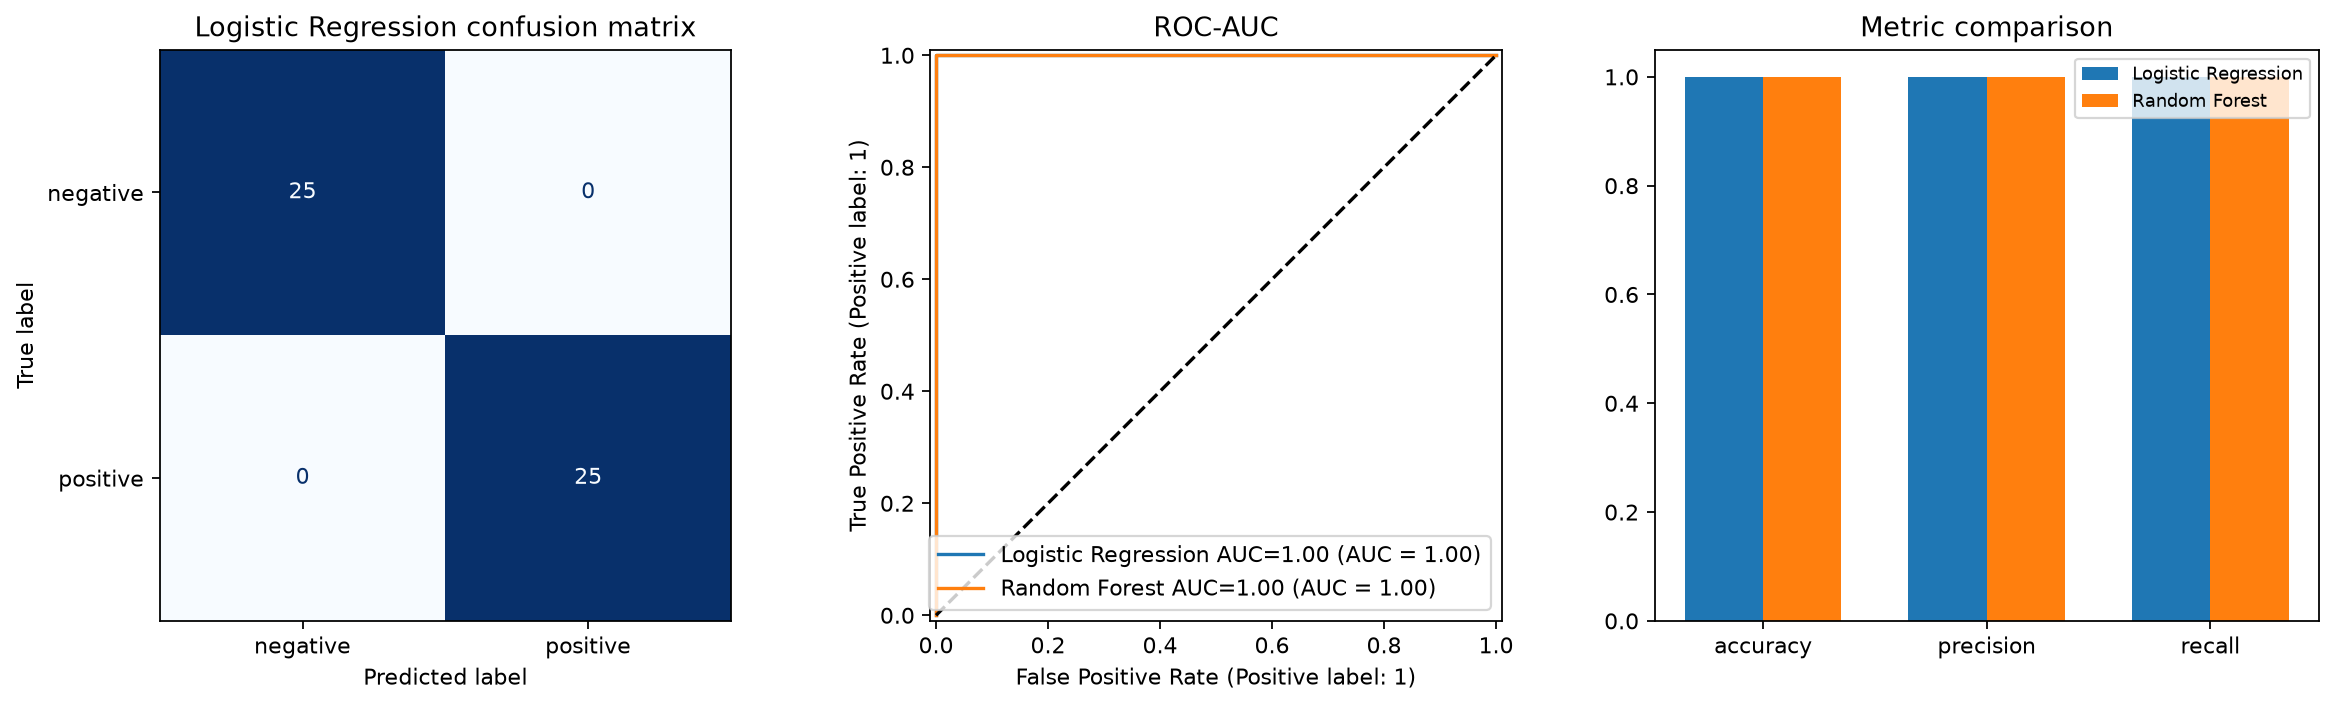

Logistic Regression: accuracy=1.000, precision=1.000, recall=1.000, ROC-AUC=1.000
Random Forest: accuracy=1.000, precision=1.000, recall=1.000, ROC-AUC=1.000
Saved: C:\cynarisis-internship\outputs\w4d5_sentiment\sentiment_pipeline.joblib


2026/10/03 10:37:28 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\cynarisis-internship\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


Logged model and metrics with MLflow
Plot: C:\cynarisis-internship\outputs\w4d5_sentiment\sentiment_evaluation.png


In [1]:
from pathlib import Path
import warnings, numpy as np
from IPython.display import display, Image
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, precision_score, recall_score, roc_auc_score
SEED=42
ROOT=Path.cwd().parent if Path.cwd().name=="week4_Notebooks" else Path.cwd()
OUT=ROOT/"outputs"/"w4d5_sentiment"; OUT.mkdir(parents=True,exist_ok=True)
positive_words=["excellent","wonderful","brilliant","delightful","fantastic","charming","superb","moving","enjoyable","captivating","impressive","heartfelt","clever","outstanding","beautiful","memorable","uplifting","terrific","fresh","rewarding"]
negative_words=["terrible","awful","dreadful","boring","tedious","annoying","weak","painful","disappointing","confusing","ugly","forgettable","miserable","clumsy","predictable","empty","irritating","poor","stale","unpleasant"]
templates=["The movie was {a} and {b}.","I found the film {a}, {b}, and worth discussing.","A {a} story with a {b} performance.","Overall this was a {a} experience and a {b} film.","Viewers will find the movie {a}; the acting is {b}."]
pos=[t.format(a=positive_words[i%len(positive_words)],b=positive_words[(i*7+3)%len(positive_words)]) for i in range(len(positive_words)) for t in templates]
neg=[t.format(a=negative_words[i%len(negative_words)],b=negative_words[(i*7+3)%len(negative_words)]) for i in range(len(negative_words)) for t in templates]
texts=pos+neg; y=np.array([1]*len(pos)+[0]*len(neg)); Xtr,Xte,ytr,yte=train_test_split(texts,y,test_size=.25,random_state=SEED,stratify=y)
models={"Logistic Regression":Pipeline([("tfidf",TfidfVectorizer(ngram_range=(1,2),sublinear_tf=True)),("model",LogisticRegression(max_iter=1000,class_weight="balanced",random_state=SEED))]),"Random Forest":Pipeline([("tfidf",TfidfVectorizer(ngram_range=(1,2),sublinear_tf=True)),("model",RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=SEED,n_jobs=-1))])}
results={}
for name,m in models.items():
 m.fit(Xtr,ytr); p=m.predict(Xte); q=m.predict_proba(Xte)[:,1]
 results[name]={"model":m,"pred":p,"prob":q,"accuracy":accuracy_score(yte,p),"precision":precision_score(yte,p,zero_division=0),"recall":recall_score(yte,p,zero_division=0),"roc_auc":roc_auc_score(yte,q)}
print("Logistic Regression classification report:"); print(classification_report(yte,results["Logistic Regression"]["pred"],labels=[0,1],target_names=["negative","positive"],zero_division=0))
fig,ax=plt.subplots(1,3,figsize=(15,4.5)); ConfusionMatrixDisplay.from_predictions(yte,results["Logistic Regression"]["pred"],display_labels=["negative","positive"],cmap="Blues",colorbar=False,ax=ax[0]); ax[0].set_title("Logistic Regression confusion matrix")
for name,r in results.items(): RocCurveDisplay.from_predictions(yte,r["prob"],name=f"{name} AUC={r['roc_auc']:.2f}",ax=ax[1])
ax[1].plot([0,1],[0,1],"k--"); ax[1].set_title("ROC-AUC")
x=np.arange(3); w=.35
for i,(name,r) in enumerate(results.items()): ax[2].bar(x+(i-.5)*w,[r[k] for k in ("accuracy","precision","recall")],w,label=name)
ax[2].set_xticks(x,["accuracy","precision","recall"]); ax[2].set_ylim(0,1.05); ax[2].legend(fontsize=8); ax[2].set_title("Metric comparison")
fig.tight_layout(); plot=OUT/"sentiment_evaluation.png"; fig.savefig(plot,dpi=160,bbox_inches="tight"); plt.close(fig); display(Image(filename=str(plot)))
for n,r in results.items(): print(f"{n}: accuracy={r['accuracy']:.3f}, precision={r['precision']:.3f}, recall={r['recall']:.3f}, ROC-AUC={r['roc_auc']:.3f}")
# Illustrative selection uses held-out AUC; production selection should use cross-validation and a final untouched test set.
best=max(results,key=lambda n:results[n]["roc_auc"]); model=results[best]["model"]
try:
 import joblib
 dest=OUT/"sentiment_pipeline.joblib"; joblib.dump(model,dest); print("Saved:",dest)
except Exception as e: warnings.warn(f"Model save failed: {e}")
try:
 import mlflow, importlib
 mlflow_sklearn=importlib.import_module("mlflow.sklearn")
 mlflow.set_tracking_uri("sqlite:///"+(OUT/"mlflow.db").resolve().as_posix()); mlflow.set_experiment("w4d5-sentiment")
 with mlflow.start_run(run_name=best.lower().replace(" ","-")):
  mlflow.log_params({"model":best,"seed":SEED,"corpus_size":len(texts)}); mlflow.log_metrics({k:float(results[best][k]) for k in ("accuracy","precision","recall","roc_auc")}); mlflow_sklearn.log_model(model,name="sentiment-model")
 print("Logged model and metrics with MLflow")
except ImportError: print("Install mlflow to log this run")
except Exception as e: warnings.warn(f"MLflow skipped: {e}")
print("Plot:",plot)
